# Exploratory Data Analysis (EDA)
Dataset: [Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

sns.set_style("whitegrid")

PROCESSED_DATA_PATH = "../data/processed/telco_customer_churn_clean.csv"

In [37]:
df = pd.read_csv(PROCESSED_DATA_PATH)
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   object 
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 


In [39]:
TARGET = "Churn"

categorical_features = [
    col for col in df.select_dtypes(include="object").columns
    if col != TARGET
]

numeric_features = df.select_dtypes(exclude="object").columns.tolist()

print("Target:", TARGET)
print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Target: Churn
Numerical features: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [40]:
df[categorical_features].nunique()

gender              2
SeniorCitizen       2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       2
InternetService     3
OnlineSecurity      2
OnlineBackup        2
DeviceProtection    2
TechSupport         2
StreamingTV         2
StreamingMovies     2
Contract            3
PaperlessBilling    2
PaymentMethod       4
dtype: int64

In [41]:
for col in categorical_features:
    print(f"\n{col}")
    print("Counts:", df[col].value_counts().to_dict())


gender
Counts: {'Male': 3549, 'Female': 3483}

SeniorCitizen
Counts: {'No': 5890, 'Yes': 1142}

Partner
Counts: {'No': 3639, 'Yes': 3393}

Dependents
Counts: {'No': 4933, 'Yes': 2099}

PhoneService
Counts: {'Yes': 6352, 'No': 680}

MultipleLines
Counts: {'No': 4065, 'Yes': 2967}

InternetService
Counts: {'Fiber optic': 3096, 'DSL': 2416, 'No': 1520}

OnlineSecurity
Counts: {'No': 5017, 'Yes': 2015}

OnlineBackup
Counts: {'No': 4607, 'Yes': 2425}

DeviceProtection
Counts: {'No': 4614, 'Yes': 2418}

TechSupport
Counts: {'No': 4992, 'Yes': 2040}

StreamingTV
Counts: {'No': 4329, 'Yes': 2703}

StreamingMovies
Counts: {'No': 4301, 'Yes': 2731}

Contract
Counts: {'Month-to-month': 3875, 'Two year': 1685, 'One year': 1472}

PaperlessBilling
Counts: {'Yes': 4168, 'No': 2864}

PaymentMethod
Counts: {'Electronic check': 2365, 'Mailed check': 1604, 'Bank transfer (automatic)': 1542, 'Credit card (automatic)': 1521}


Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64


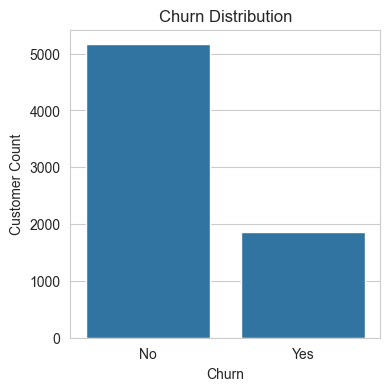

Churn
No     0.734
Yes    0.266
Name: proportion, dtype: float64

In [42]:
print(df[TARGET].value_counts())
print(df[TARGET].value_counts(normalize=True))

plt.figure(figsize=(4,4))
sns.countplot(x=TARGET, data=df)
plt.title("Churn Distribution")
plt.xlabel(TARGET)
plt.ylabel("Customer Count")
plt.show()

df[TARGET].value_counts(normalize=True).round(3)

In [43]:
df[categorical_features].describe().T

,count,unique,top,freq
gender,7032,2,Male,3549
SeniorCitizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,4933
PhoneService,7032,2,Yes,6352
MultipleLines,7032,2,No,4065
InternetService,7032,3,Fiber optic,3096
OnlineSecurity,7032,2,No,5017
OnlineBackup,7032,2,No,4607
DeviceProtection,7032,2,No,4614


In [44]:
df[numeric_features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


In [45]:
df.groupby(TARGET)[numeric_features].agg(["mean", "median", "std"]).round(2)

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.65   38.0  24.08          61.31  64.45  31.09      2555.34  1683.60   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.46  
Yes    1890.82

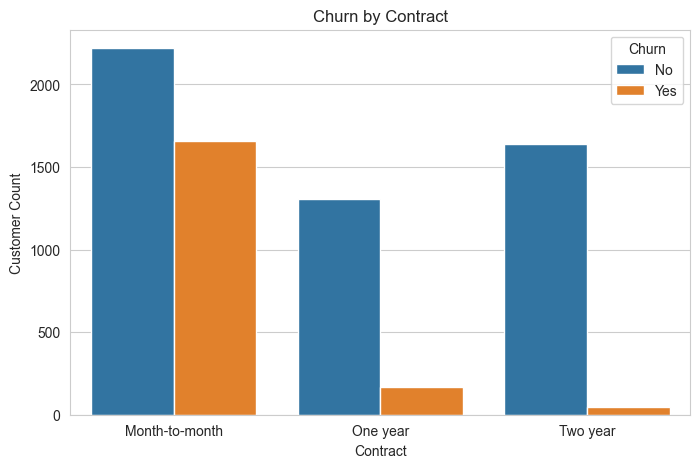

Churn rate by Contract:



Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


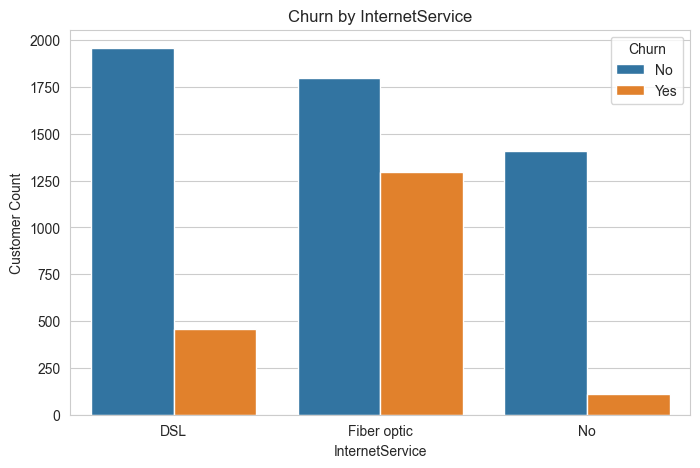

Churn rate by InternetService:



Churn,No,Yes
InternetService,,
DSL,0.810,0.190
Fiber optic,0.581,0.419
No,0.926,0.074


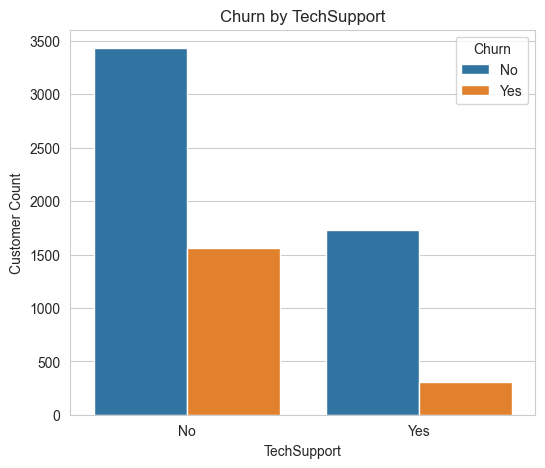

Churn rate by TechSupport:



Churn,No,Yes
TechSupport,,
No,0.688,0.312
Yes,0.848,0.152


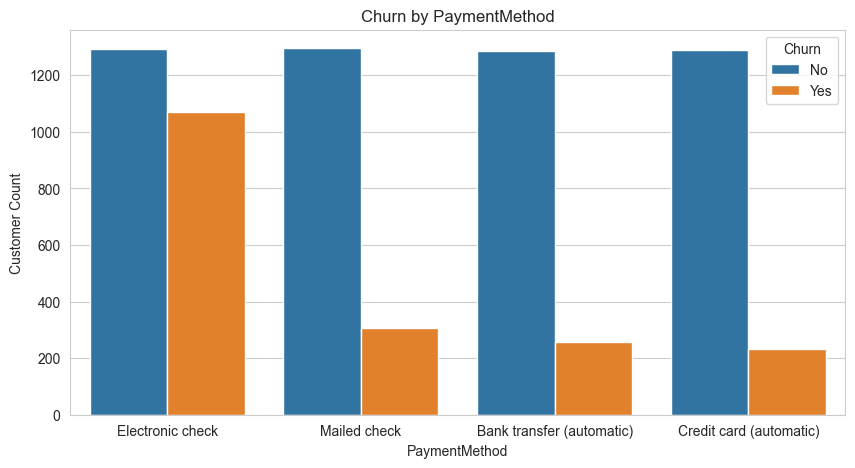

Churn rate by PaymentMethod:



Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.847,0.153
Electronic check,0.547,0.453
Mailed check,0.808,0.192


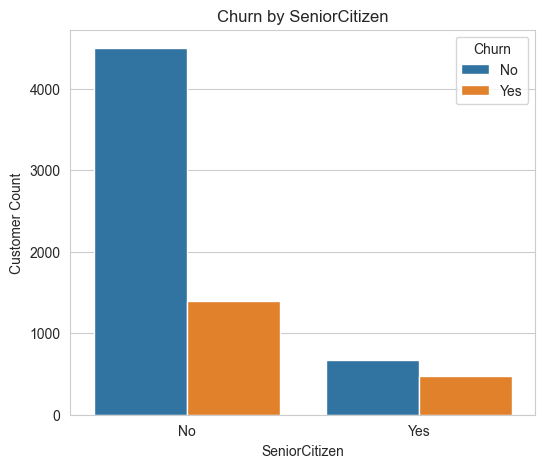

Churn rate by SeniorCitizen:



Churn,No,Yes
SeniorCitizen,,
No,0.763,0.237
Yes,0.583,0.417


In [46]:
def plot_churn_analysis(df, column, target, height=5):
    
    # Dynamic width based on number of categories
    n_unique = df[column].nunique()
    width = n_unique * 2 + 2
    
    # Plot
    plt.figure(figsize=(width, height))
    sns.countplot(x=column, hue=target, data=df)
    plt.title(f"Churn by {column}")
    plt.xlabel(column)
    plt.ylabel("Customer Count")
    plt.legend(title=target)
    plt.show()
    
    # Crosstab
    print(f"Churn rate by {column}:\n")
    crosstab = pd.crosstab(df[column], df[target], normalize="index").round(3)
    display(crosstab)

key_categorical_features = [
    "Contract",
    "InternetService",
    "TechSupport",
    "PaymentMethod",
    "SeniorCitizen"
]

for col in key_categorical_features:
    plot_churn_analysis(df, col, TARGET)

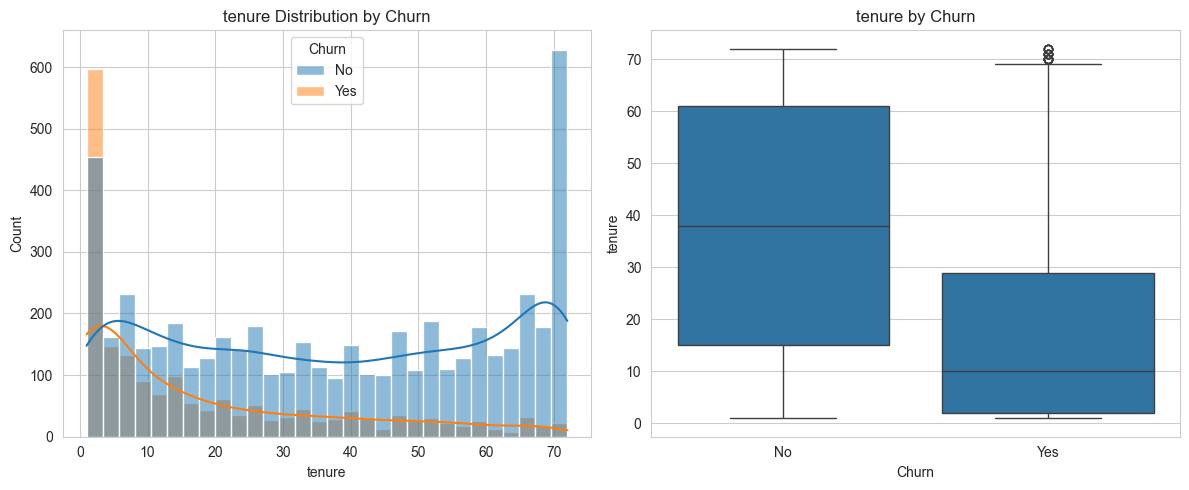

Summary statistics for tenure:



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


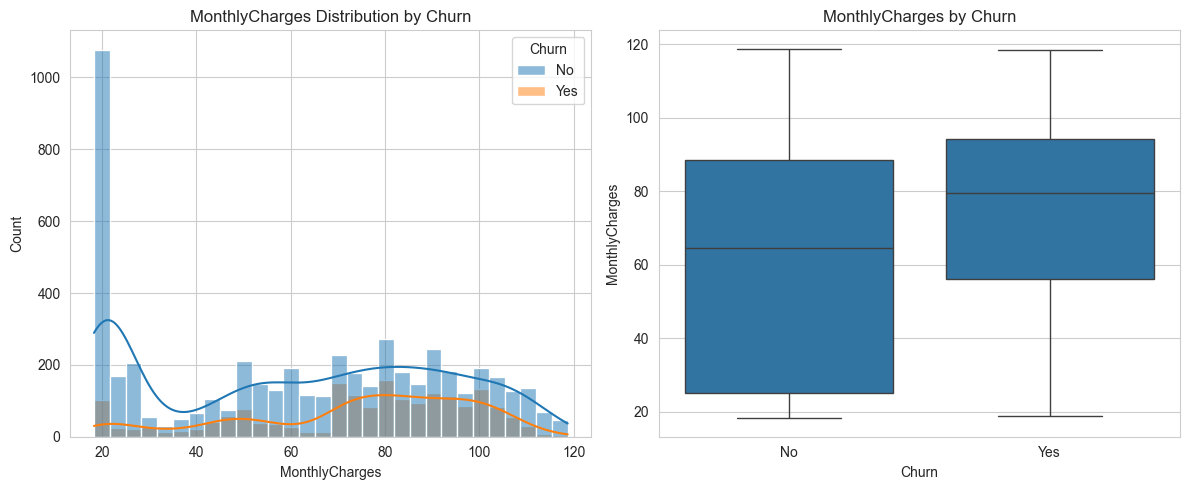

Summary statistics for MonthlyCharges:



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.31,31.09,18.25,25.10,64.45,88.48,118.75
Yes,1869.0,74.44,24.67,18.85,56.15,79.65,94.20,118.35


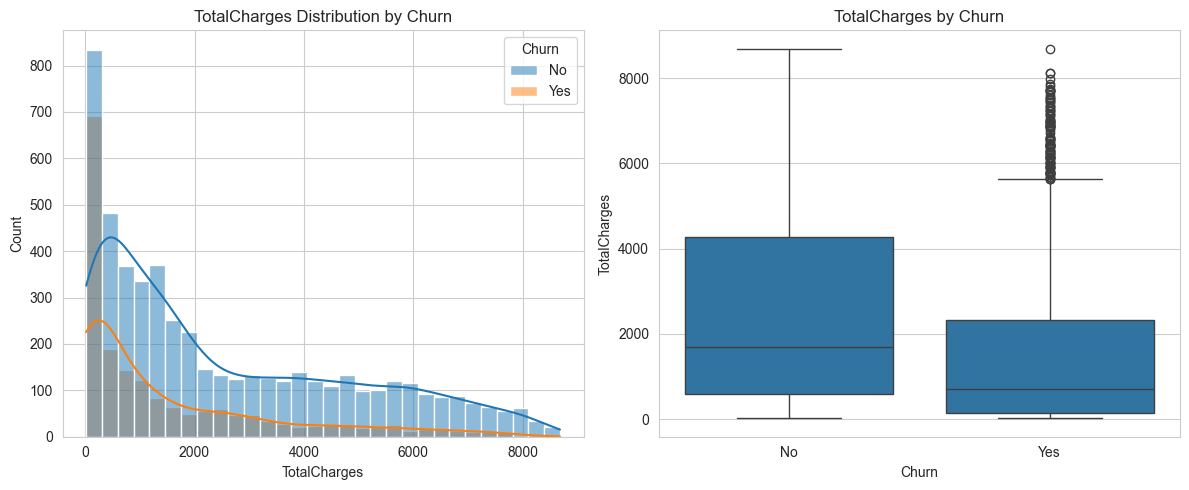

Summary statistics for TotalCharges:



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.34,2329.46,18.80,577.83,1683.60,4264.12,8672.45
Yes,1869.0,1531.80,1890.82,18.85,134.50,703.55,2331.30,8684.80


In [47]:
def plot_numeric_churn_analysis(df, column, target, height=5):
        
    fig, axes = plt.subplots(1, 2, figsize=(12, height))
    
    # Histogram
    sns.histplot(
        data=df,
        x=column,
        hue=target,
        bins=30,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"{column} Distribution by {target}")
    
    # Boxplot
    sns.boxplot(
        data=df,
        x=target,
        y=column,
        ax=axes[1]
    )
    axes[1].set_title(f"{column} by {target}")
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    stats = df.groupby(target)[column].describe().round(2)

    print(f"Summary statistics for {column}:\n")
    display(stats)

for col in numeric_features:
    plot_numeric_churn_analysis(df, col, TARGET)